# Feature - Education

## Import relevant libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import kagglehub
import torch
import cv2
from IPython.core.pylabtools import figsize
from scipy.spatial import distance
from torchvision.datasets import ImageFolder
from torchvision import transforms
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

## Loading and Converting Dataset

### Setup Transformers

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
]) 

### Define Folder Paths

In [4]:
ROOT_DIR = "../../dataset/Dataset"
TEXT_TRAIN_CSV = os.path.join(ROOT_DIR, "Texts", "Education", "Education_Train.csv")
TEXT_TEST_CSV = os.path.join(ROOT_DIR, "Texts", "Education", "Education_Test.csv")

IMAGE_TRAIN = os.path.join(ROOT_DIR, "Images", "Education", "train")
IMAGE_TEST = os.path.join(ROOT_DIR, "Images", "Education", "test")

### Creating the dataset

In [5]:
train_dataset = ImageFolder(IMAGE_TRAIN, transform=transform)
test_dataset = ImageFolder(IMAGE_TEST, transform=transform)

### Load text data

In [6]:
columns = [
    "image_name",
    "text_tr",
    "text_en",
    "education",
    "extra"
]

train_df = pd.read_csv(TEXT_TRAIN_CSV, header=None, names=columns)
test_df  = pd.read_csv(TEXT_TEST_CSV, header=None, names=columns)

In [7]:
train_df.head()

,image_name,text_tr,text_en,education,extra
0,205-5G-1242-F-H,Birinci olmak çok gurur verici ve mutlu bir şe...,Being the first is a very proud and happy thin...,Secondary,NaN
1,210-5C-818-F-H,Mutluluk hayattaki ışıktır,Happiness is the light in life,Secondary,NaN
2,214-6B-421-F-S,Mutsuzluk benim için üzüldükten sonra asla pes...,Unhappiness is never giving up after feeling s...,Secondary,NaN
3,206-6D-790-F-S,"Benim için üzüntü haksızlığa uğramak, dışlanma...","For me, sadness is being wronged, being exclud...",Secondary,NaN
4,203-5H-720-F-H,Benim için mutluluk dünyada kötülüğün olmadığı...,"For me, happiness is a world where there is no...",Secondary,NaN


In [8]:
test_df.head()

,image_name,text_tr,text_en,education,extra
0,205-5D-417-F-H,"Ağaçlar, kuşlar ve en büyük mutluluğumdur","Trees, birds and my greatest happiness",Secondary,NaN
1,207-6H-282-M-H,Doğa deniz ve yeşil yerler beni mutluluğumdur,"Nature, sea and green places are my happiness",Secondary,NaN
2,280-5M-84-F-H,Bu resimde bana arkadaşına hediye alan ve bu k...,"In this picture, It tells me that she bought a...",Secondary,NaN
3,250-5C-1276-M-S,Pazar dönüşündeki yağmur,Rain on Sunday return,Secondary,NaN
4,210-5C-786-F-S,"Keşke o kötülüğü yapmasaydım, yalnız olmazdım","I wish I had not done that evil, I would not b...",Secondary,NaN


## Exploring the Invalid Data

In [9]:
train_df['extra'].value_counts()

extra
something joyful love    1
Name: count, dtype: int64

In [10]:
test_df['extra'].value_counts()

Series([], Name: count, dtype: int64)

### Manipulate the invalid rows

In [11]:
invalid_row = train_df[train_df["extra"].notna()]
invalid_row

,image_name,text_tr,text_en,education,extra
6234,108-3B-457-M-H,Mutluluk,sevinçli bir şey sevgi,Primary,something joyful love


In [12]:
train_df.loc[train_df["extra"].notna(), "text_en"] = train_df.loc[
    train_df["extra"].notna(), "extra"
]

In [13]:
train_df[train_df["extra"].notna()][["text_en", "extra"]]

,text_en,extra
6234,something joyful love,something joyful love


### Drop Unnecessary Row

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9228 entries, 0 to 9227
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  9228 non-null   object
 1   text_tr     9226 non-null   object
 2   text_en     9226 non-null   object
 3   education   9228 non-null   object
 4   extra       1 non-null      object
dtypes: object(5)
memory usage: 360.6+ KB


In [15]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_name  1632 non-null   object 
 1   text_tr     1632 non-null   object 
 2   text_en     1632 non-null   object 
 3   education   1632 non-null   object 
 4   extra       0 non-null      float64
dtypes: float64(1), object(4)
memory usage: 63.9+ KB


In [16]:
train_df.describe(include='all')

,image_name,text_tr,text_en,education,extra
count,9228,9226,9226,9228,1
unique,9228,8892,8730,2,1
top,205-5G-1242-F-H,Mutluluk benim için doğadır,Happiness is nature for me,Secondary,something joyful love
freq,1,13,15,4614,1


In [17]:
test_df.describe(include='all')

,image_name,text_tr,text_en,education,extra
count,1632,1632,1632,1632,0.0
unique,1632,1610,1594,2,NaN
top,205-5D-417-F-H,Mutluluk benim için ailedir,I am very sad today,Secondary,NaN
freq,1,4,5,816,NaN
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN


In [18]:
train_df.columns.values

array(['image_name', 'text_tr', 'text_en', 'education', 'extra'],
      dtype=object)

In [19]:
test_df.columns.values

array(['image_name', 'text_tr', 'text_en', 'education', 'extra'],
      dtype=object)

In [20]:
train_df = train_df.drop(columns=["text_tr", "extra"])
test_df = test_df.drop(columns=["text_tr", "extra"])

In [21]:
train_df.head()

,image_name,text_en,education
0,205-5G-1242-F-H,Being the first is a very proud and happy thin...,Secondary
1,210-5C-818-F-H,Happiness is the light in life,Secondary
2,214-6B-421-F-S,Unhappiness is never giving up after feeling s...,Secondary
3,206-6D-790-F-S,"For me, sadness is being wronged, being exclud...",Secondary
4,203-5H-720-F-H,"For me, happiness is a world where there is no...",Secondary


In [22]:
test_df.head()

,image_name,text_en,education
0,205-5D-417-F-H,"Trees, birds and my greatest happiness",Secondary
1,207-6H-282-M-H,"Nature, sea and green places are my happiness",Secondary
2,280-5M-84-F-H,"In this picture, It tells me that she bought a...",Secondary
3,250-5C-1276-M-S,Rain on Sunday return,Secondary
4,210-5C-786-F-S,"I wish I had not done that evil, I would not b...",Secondary


## Exploring the Text Data

### Shape

In [23]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (9228, 3)
Test shape: (1632, 3)


### Data types & Missing Values

In [24]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9228 entries, 0 to 9227
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  9228 non-null   object
 1   text_en     9226 non-null   object
 2   education   9228 non-null   object
dtypes: object(3)
memory usage: 216.4+ KB


In [25]:
train_df.isnull().sum()

image_name    0
text_en       2
education     0
dtype: int64

In [26]:
missing_text = train_df[train_df["text_en"].isna()]
missing_text

,image_name,text_en,education
54,214-5K-1917-M-H,NaN,Secondary
3326,214-5K-348-M-H,NaN,Secondary


In [27]:
train_df = train_df.dropna(subset=["text_en"])
test_df  = test_df.dropna(subset=["text_en"])

In [28]:
train_df.isnull().sum()

image_name    0
text_en       0
education     0
dtype: int64

In [29]:
test_df.isnull().sum()

image_name    0
text_en       0
education     0
dtype: int64

In [31]:
train_df['education'].value_counts()

education
Primary      4614
Secondary    4612
Name: count, dtype: int64

### Target Variable and Class Balance

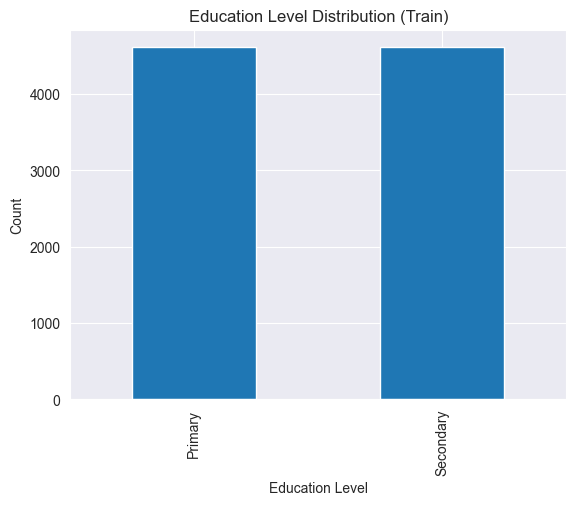

In [32]:
train_df['education'].value_counts().plot(kind='bar')
plt.title("Education Level Distribution (Train)")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

### Word Count Interpretation

In [34]:
train_df['word_count'] = train_df['text_en'].apply(lambda x: len(x.split()))
test_df['word_count'] = test_df['text_en'].apply(lambda x: len(x.split()))

In [35]:
train_df['word_count'].describe()

count    9226.000000
mean       10.976588
std         8.593392
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max       127.000000
Name: word_count, dtype: float64

### Word count by Education

<Axes: xlabel='word_count', ylabel='education'>

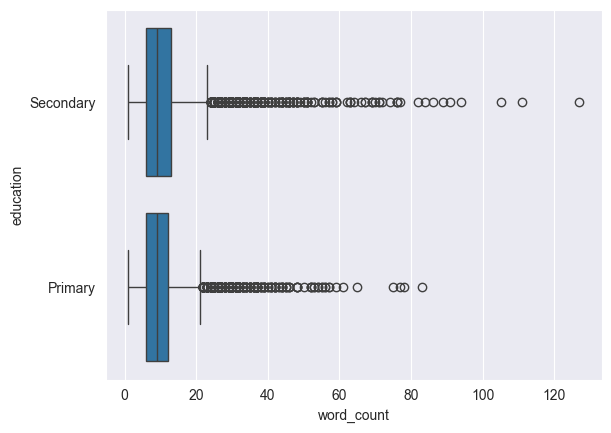

In [36]:
sns.boxplot(x="word_count", y="education", data=train_df)

In [37]:
train_df.groupby('education')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
Primary,4614.0,10.480494,7.388124,1.0,6.0,9.0,12.0,83.0
Secondary,4612.0,11.472897,9.624974,1.0,6.0,9.0,13.0,127.0


In [38]:
train_df['word_count'].describe(), test_df['word_count'].describe()

(count    9226.000000
 mean       10.976588
 std         8.593392
 min         1.000000
 25%         6.000000
 50%         9.000000
 75%        13.000000
 max       127.000000
 Name: word_count, dtype: float64,
 count    1632.000000
 mean       10.438113
 std         7.048129
 min         1.000000
 25%         6.000000
 50%         9.000000
 75%        12.000000
 max        94.000000
 Name: word_count, dtype: float64)

### Exploring Vocabulary 

In [40]:
all_words = " ".join(train_df['text_en']).lower().split()

vocab = Counter(all_words)

len(vocab)

4869

In [41]:
single_occurrence = sum(1 for v in vocab.values() if v == 1)
single_occurrence

2363

Text has moderate vocabulary diversity and has a high sparsity.

Supports using: 
* TF-IDF (Term Frequency - Inverse Document Frequency) with min_df 
* Subword tokenization (BERT)

### Top 20 most frequent words 

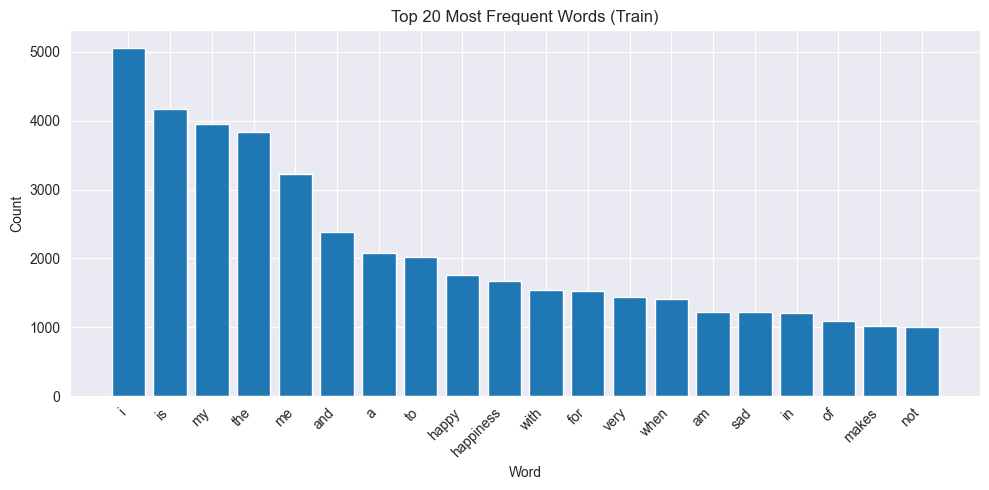

In [45]:
top = vocab.most_common(20)
top_words = [w for w, c in top]
top_counts = [c for w, c in top]

plt.figure(figsize=(10,5))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Frequent Words (Train)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Top words (stopwords removed)

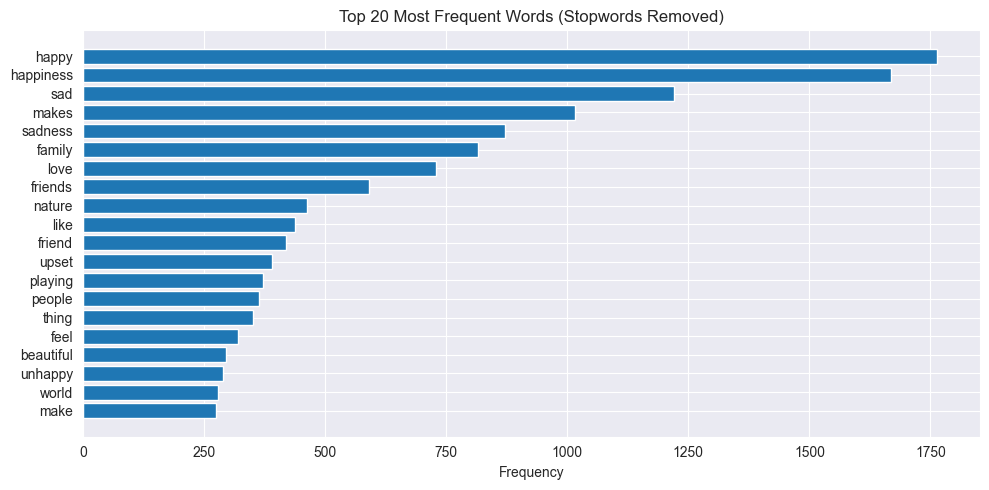

In [47]:
stop = set(ENGLISH_STOP_WORDS)

words = [w for w in all_words if w.isalpha() and w not in stop]

freq = Counter(words)
top = freq.most_common(20)

labels = [w for w, c in top]
counts = [c for w, c in top]

plt.figure(figsize=(10,5))
plt.barh(labels, counts)
plt.gca().invert_yaxis()
plt.title("Top 20 Most Frequent Words (Stopwords Removed)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [50]:
print(labels)
print(counts)

['happy', 'happiness', 'sad', 'makes', 'sadness', 'family', 'love', 'friends', 'nature', 'like', 'friend', 'upset', 'playing', 'people', 'thing', 'feel', 'beautiful', 'unhappy', 'world', 'make']
[1764, 1669, 1220, 1016, 872, 815, 729, 591, 463, 439, 420, 391, 371, 364, 351, 321, 295, 289, 278, 275]


Interpretation:

* Dataset is emotion-centered
* Strong affective terms - happy, sad, happiness, sadness, unhappy
* Social context words - family, friends, friend, people

The vocabulary is semantically aligned with emotional expression, supporting the hypothesis that linguistic patterns can be used to distinguish education levels. 


### Per-class word comparison (Primary vs Secondary)

In [51]:
def top_words_by_class(df, label, n=20):
    words = " ".join(df[df["education"] == label]["text_en"]).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop]
    return Counter(words).most_common(n)

In [52]:
primary_top = top_words_by_class(train_df, "Primary")
secondary_top = top_words_by_class(test_df, "Secondary")

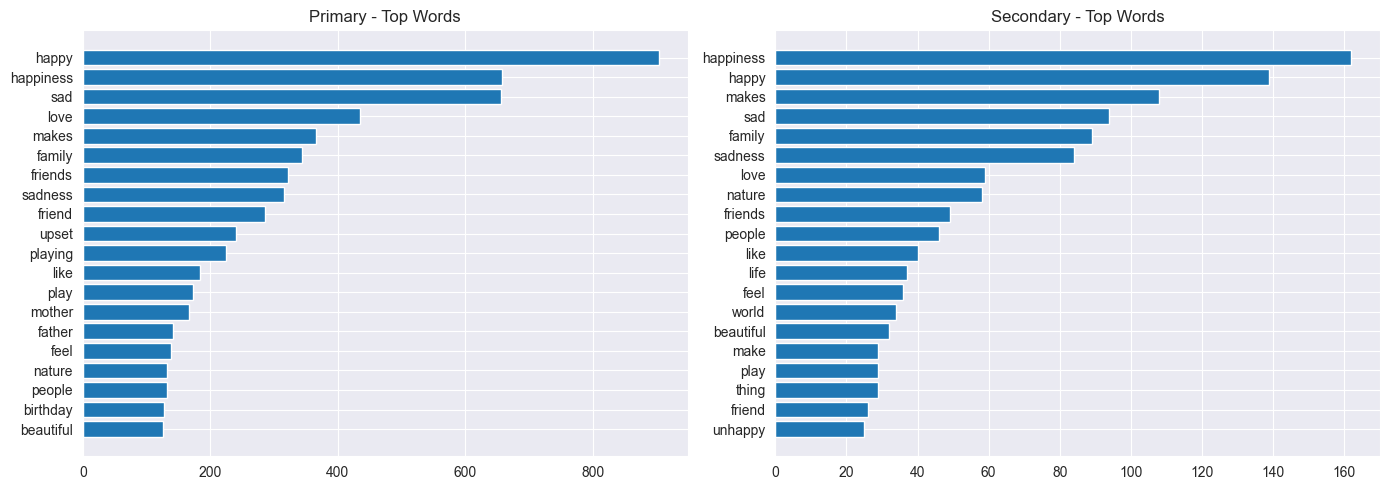

In [53]:
p_words, p_counts = zip(*primary_top)
s_words, s_counts = zip(*secondary_top)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

axes[0].barh(p_words, p_counts)
axes[0].invert_yaxis()
axes[0].set_title("Primary - Top Words")

axes[1].barh(s_words, s_counts)
axes[1].invert_yaxis()
axes[1].set_title("Secondary - Top Words")

plt.tight_layout()
plt.show()

While both classes express emotions, Primary texts tend to focus on immediate experience, where Secondary texts reflect broader emotional and social contexts.

## Summary of Findings

* The dataset is well-balanced between Primary and Secondary classes, with only a negligible imbalance after removing missing values.

* Text samples are short (median ≈ 9 words), making this a short-text classification task.

* Vocabulary size is moderate (4,869 unique words) with a high proportion of rare words (~48%), indicating linguistic diversity and sparsity.

* Frequent words are emotion-centric, focusing on feelings and social contexts.

* Per-class analysis shows:

    - Primary texts emphasize concrete emotions and activities.

    - Secondary texts use more abstract and reflective language.

* Train and test distributions are consistent, with no data leakage concerns.